In [1]:
# Mount ổ đĩa
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

%cd '/content/gdrive/MyDrive/Project'

Mounted at /content/gdrive
/content/gdrive/MyDrive/Project


## 1.Cài đặt các thư viện và môi trường cần thiết

In [2]:
# Update hệ điều hành và cài đặt JDK 11
!apt update
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
50 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InR

In [3]:
!chmod +x /content/gdrive/MyDrive/LDS9_DL06_K297_MaiAnhSon/Spark/spark-3.5.1-bin-hadoop3/bin/*

In [4]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# Khai báo đường dẫn đến thư mục đã giải nén
os.environ["SPARK_HOME"] = "/content/gdrive/MyDrive/LDS9_DL06_K297_MaiAnhSon/Spark/spark-3.5.1-bin-hadoop3"

In [5]:
# Cài đặt thư viện "findspark"
!pip install -q findspark

In [6]:
import findspark
findspark.init()

In [7]:
import pyspark
from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.conf import SparkConf

In [8]:
spark = SparkSession.builder.appName('Collaborative_filtering').getOrCreate()

## 2.ALS

### 2.1 Đọc dữ liệu

Dữ liệu khi đọc với pyspark bị lỗi nhảy dòng cột so_sao và ma_san_pham, nên kiểu dữ liệu của cột so_sao và ma_san_pham đều là string. Nhưng khi đọc dữ liệu với pandas thì không bị lỗi => nên thực hiện đọc file bằng pandas rồi chuyển qua pyspark.

In [9]:
import pandas as pd
df = pd.read_csv("data/Danh_gia.csv")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21575 entries, 0 to 21574
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  21575 non-null  int64 
 1   ma_khach_hang       21575 non-null  int64 
 2   noi_dung_binh_luan  20674 non-null  object
 3   ngay_binh_luan      21575 non-null  object
 4   gio_binh_luan       21575 non-null  object
 5   so_sao              21575 non-null  int64 
 6   ma_san_pham         21575 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 1.2+ MB


In [11]:
df_ratings = spark.createDataFrame(df)

In [12]:
df_ratings.printSchema()

root
 |-- id: long (nullable = true)
 |-- ma_khach_hang: long (nullable = true)
 |-- noi_dung_binh_luan: string (nullable = true)
 |-- ngay_binh_luan: string (nullable = true)
 |-- gio_binh_luan: string (nullable = true)
 |-- so_sao: long (nullable = true)
 |-- ma_san_pham: long (nullable = true)



Khi chuyển từ pandas DataFrame sang PySpark DataFrame, kiểu dữ liệu số nguyên (int64) trong pandas mặc định được chuyển thành kiểu long (LongType) trong PySpark
Nguyên nhân:
- Trong pandas, int64 được sử dụng cho các số nguyên lớn.
- Khi chuyển sang PySpark, PySpark coi tất cả các số nguyên lớn là kiểu LongType vì kiểu IntegerType trong PySpark chỉ hỗ trợ phạm vi nhỏ hơn (-2,147,483,648 đến 2,147,483,647).
- Để xử lý dữ liệu lớn một cách an toàn, PySpark sử dụng LongType (64-bit) mặc định.

In [13]:
df_ratings.show(3)

+---+-------------+--------------------+--------------+-------------+------+-----------+
| id|ma_khach_hang|  noi_dung_binh_luan|ngay_binh_luan|gio_binh_luan|so_sao|ma_san_pham|
+---+-------------+--------------------+--------------+-------------+------+-----------+
|  1|          443|SỬ DỤNG DỄ DÀNG, ...|    29/04/2023|        17:06|     5|  308500015|
|  2|         1030|Sử dụng dễ dãng,r...|    30/04/2023|        15:04|     5|  308500015|
|  3|          689|Mình rất thích ha...|    30/04/2023|        18:34|     5|  422216594|
+---+-------------+--------------------+--------------+-------------+------+-----------+
only showing top 3 rows



In [14]:
df_ratings = df_ratings.select("ma_khach_hang", "ma_san_pham", "so_sao")

In [15]:
df_ratings.count()

21575

### 2.2 Kiểm tra dữ liệu

In [16]:
from pyspark.sql import functions as f
from pyspark.sql.functions import *

In [17]:
# Check dữ liệu null
df_ratings.select([count(when(col(c).isNull(), c)).alias(c) for c in df_ratings.columns]).toPandas().T

,0
ma_khach_hang,0
ma_san_pham,0
so_sao,0


In [18]:
df_ratings.printSchema()

root
 |-- ma_khach_hang: long (nullable = true)
 |-- ma_san_pham: long (nullable = true)
 |-- so_sao: long (nullable = true)



In [19]:
# Distinct users and movies
users = df_ratings.select("ma_khach_hang").distinct().count()
products = df_ratings.select("ma_san_pham").distinct().count()
numerator = df_ratings.count()

display(numerator, users, products)

21575

4485

686

In [20]:
# Number of ratings matrix could contain if no empty cells
denominator = users * products
denominator

3076710

Vì ma_san_pham, ma_khach_hang và so_sao đã là số nguyên nên không cần schuẩn hóa dữ liệu

### 2.2 Chia dữ liệu train-test

In [21]:
# Tạo tập train/test
train_data, test_data = df_ratings.select("ma_khach_hang", "ma_san_pham", "so_sao").randomSplit([0.8, 0.2], seed=42)

In [22]:
train_data.count()

17380

In [23]:
test_data.count()

4195

### 2.3 Xây dựng model

In [24]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS

In [25]:
als = ALS(maxIter=10,
          regParam=0.09,
          userCol="ma_khach_hang",
          itemCol="ma_san_pham",
          ratingCol="so_sao",
          coldStartStrategy="drop",
          nonnegative=True)
model = als.fit(train_data)

### 2.4 Đánh giá kết quả

In [26]:
# Evaluate the model by computing the RMSE on the test data
predictions = model.transform(test_data)

In [27]:
predictions.show(5)

+-------------+-----------+------+----------+
|ma_khach_hang|ma_san_pham|so_sao|prediction|
+-------------+-----------+------+----------+
|          148|  205100146|     5|   4.78496|
|          148|  422210980|     5| 4.7948585|
|         1088|  422204231|     5| 4.5514336|
|         1088|  422204904|     5|  4.842543|
|         1342|  100250032|     5|  3.744125|
+-------------+-----------+------+----------+
only showing top 5 rows



In [28]:
# Tạo evaluator cho các chỉ số khác nhau
evaluator_rmse = RegressionEvaluator(metricName="rmse", labelCol="so_sao", predictionCol="prediction")
evaluator_r2 = RegressionEvaluator(metricName="r2", labelCol="so_sao", predictionCol="prediction")
evaluator_mse = RegressionEvaluator(metricName="mse", labelCol="so_sao", predictionCol="prediction")

# Tính toán RMSE, R2, và MSE
rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)
mse = evaluator_mse.evaluate(predictions)

# In ra kết quả
print("Root-mean-square error (RMSE) = " + str(rmse))
print("R-squared (R2) = " + str(r2))
print("Mean-squared error (MSE) = " + str(mse))

Root-mean-square error (RMSE) = 0.674801307641421
R-squared (R2) = 0.39867509258381584
Mean-squared error (MSE) = 0.45535680479457175


=> Kết quả RMSE = 0.66 cho thấy mô hình ALS đang hoạt động tốt, dự đoán gần đúng với so_sao thực tế.

### 2.5 Lưu model

In [29]:
model.save('project2/ALSModel3')

### 2.6 Đưa ra đề xuất cho khách hàng

In [30]:
from pyspark.ml.recommendation import ALSModel

# Tải lại model ALS
ALS_model = ALSModel.load('project2/ALSModel3')

In [31]:
df_products = spark.read.csv("data/San_pham.csv", header=True, inferSchema=True,
                             multiLine=True, # Xử lý các giá trị nhiều dòng
                             escape="") # Ký tự thoát (escape) cho giá trị chứa ký tự xuống dòng
df_customers = spark.read.csv("data/Khach_hang.csv", header=True, inferSchema=True,
                              multiLine=True,
                              escape="")

In [32]:
# Tạo bảng bổ sung thêm thông tin tên sản phẩm và tên khách hàng
df_joined = df_ratings.join(df_customers, on='ma_khach_hang')
df_final = df_joined.join(df_products, on="ma_san_pham")

# Chọn các cột cần thiết
df_final = df_final.select("ma_khach_hang", "ma_san_pham", "so_sao", "ho_ten", "ten_san_pham", "gia_ban")
df_final.show(3)

+-------------+-----------+------+--------------------+--------------------+-------+
|ma_khach_hang|ma_san_pham|so_sao|              ho_ten|        ten_san_pham|gia_ban|
+-------------+-----------+------+--------------------+--------------------+-------+
|          443|  308500015|     5|Nguyễn Thị Tuyết Hoa|Mặt Nạ Naruko Bạc...|  20000|
|         1030|  308500015|     5|    Nguyễn phong lan|Mặt Nạ Naruko Bạc...|  20000|
|          689|  422216594|     5|           Vy Nguyen|Combo 2 Nước Tẩy ...| 730000|
+-------------+-----------+------+--------------------+--------------------+-------+
only showing top 3 rows



In [33]:
# Tạo DataFrame với ma_khach_hang cụ thể
user_df = spark.createDataFrame([(443,)], ["ma_khach_hang"])

# Kiểm tra kết quả schema
user_df.printSchema()

root
 |-- ma_khach_hang: long (nullable = true)



In [34]:
recommendations = ALS_model.recommendForUserSubset(user_df, numItems=5)

# Kiểm tra schema của kết quả trả về
recommendations.printSchema() # cột dự đoán được mô hình trả ra là rating

root
 |-- ma_khach_hang: integer (nullable = false)
 |-- recommendations: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- ma_san_pham: integer (nullable = true)
 |    |    |-- rating: float (nullable = true)



In [35]:
recommendations.show(truncate=False)

+-------------+----------------------------------------------------------------------------------------------------------------------+
|ma_khach_hang|recommendations                                                                                                       |
+-------------+----------------------------------------------------------------------------------------------------------------------+
|443          |[{422202632, 7.4568048}, {422205673, 7.3773284}, {308500001, 6.3860245}, {204100024, 6.35454}, {422217480, 6.3530498}]|
+-------------+----------------------------------------------------------------------------------------------------------------------+



In [36]:
def recommend_for_user(customer_id=None, customer_name=None):
    if customer_name is not None:
        # Lấy customer_id từ customer_name
        customer_id = df_customers.filter(col("ho_ten") == customer_name).select("ma_khach_hang").head()[0]

    # Tạo DataFrame từ customer_id để dự đoán
    user_df = spark.createDataFrame([(customer_id,)], ["ma_khach_hang"]) # (customer_id,) sử dụng dấu , để tạo một tuple với phần tử customer_id, để DataFrame sẽ được tạo đúng.

    # Đề xuất sản phẩm
    recommendations = ALS_model.recommendForUserSubset(user_df, numItems=5)

    # Truy xuất sản phẩm được đề xuất (lấy các sản phẩm và rating)
    recs = recommendations.select("recommendations").collect()[0][0]

    # Lấy các itemId và ratings từ kết quả đề xuất
    recommended_product_ids = [row["ma_san_pham"] for row in recs]  # itemId sẽ là id sản phẩm
    recommended_ratings = [row["rating"] for row in recs]  # rating là điểm đánh giá được dự đoán

    # Tạo DataFrame chứa sản phẩm được đề xuất
    recommended_df = spark.createDataFrame(zip(recommended_product_ids, recommended_ratings), ["ma_san_pham", "predicted_rating"])

    # Join với bảng sản phẩm để lấy tên sản phẩm và giá bán
    result_df = recommended_df.join(df_products, "ma_san_pham").join(df_customers, col("ma_khach_hang") == customer_id)\
        .filter(col("predicted_rating") > 3).select("ma_khach_hang", "ho_ten", "ma_san_pham", "ten_san_pham", "gia_ban", "predicted_rating")

    # Hiển thị kết quả
    result_df.show(truncate=False)


In [37]:
# Đề xuất theo mã customerId
recommend_for_user(customer_id=443)

+-------------+--------------------+-----------+------------------------------------------------------+-------+------------------+
|ma_khach_hang|ho_ten              |ma_san_pham|ten_san_pham                                          |gia_ban|predicted_rating  |
+-------------+--------------------+-----------+------------------------------------------------------+-------+------------------+
|443          |Nguyễn Thị Tuyết Hoa|422202632  |Kem Dưỡng Bio-essence Cấp Ẩm Sâu, Ngăn Bụi Bẩn 50g    |335000 |7.4568047523498535|
|443          |Nguyễn Thị Tuyết Hoa|422205673  |Kem Dưỡng Cocoon Dạng Thạch Bí Đao Giảm Dầu & Mụn 30ml|175000 |7.377328395843506 |
|443          |Nguyễn Thị Tuyết Hoa|308500001  |Sữa Rửa Mặt Naruko Dạng Bùn Tràm Trà 120ml            |165000 |6.386024475097656 |
|443          |Nguyễn Thị Tuyết Hoa|204100024  |Toner Eucerin Dành Cho Da Nhờn Mụn 200ml              |311000 |6.35453987121582  |
|443          |Nguyễn Thị Tuyết Hoa|422217480  |Toner Eucerin Dành Cho Da Nhờn Mụn 

In [38]:
# In ra các sản phẩm đã mua
df_final.filter(col('ma_khach_hang') == 443).show(truncate=False)

+-------------+-----------+------+--------------------+-----------------------------------------------------------+-------+
|ma_khach_hang|ma_san_pham|so_sao|ho_ten              |ten_san_pham                                               |gia_ban|
+-------------+-----------+------+--------------------+-----------------------------------------------------------+-------+
|443          |308500015  |5     |Nguyễn Thị Tuyết Hoa|Mặt Nạ Naruko Bạch Ngọc Lan Dưỡng Sáng, Săn Chắc Da 30ml   |20000  |
|443          |204100054  |5     |Nguyễn Thị Tuyết Hoa|Gel Rửa Mặt Eucerin Cho Da Nhờn Mụn 400ml                  |448000 |
|443          |422206537  |5     |Nguyễn Thị Tuyết Hoa|Gel Rửa Mặt Eucerin Cho Da Nhờn Mụn 75ml                   |179000 |
|443          |422202253  |5     |Nguyễn Thị Tuyết Hoa|Mặt Nạ Naruko Ý Dĩ Nhân Đỏ Dưỡng Sáng Da 25ml (Mới)        |23000  |
|443          |422205162  |5     |Nguyễn Thị Tuyết Hoa|Hộp 10 Miếng Mặt Nạ Naruko Hoa Hồng Nhung Cấp Nước 25ml/M  |238000 |
|443    

In [39]:
# Đề xuất theo tên khách hàng
recommend_for_user(customer_name="Nguyễn phong lan")

+-------------+----------------+-----------+--------------------------------------------------------+-------+-----------------+
|ma_khach_hang|ho_ten          |ma_san_pham|ten_san_pham                                            |gia_ban|predicted_rating |
+-------------+----------------+-----------+--------------------------------------------------------+-------+-----------------+
|1030         |Nguyễn phong lan|422202632  |Kem Dưỡng Bio-essence Cấp Ẩm Sâu, Ngăn Bụi Bẩn 50g      |335000 |7.603785991668701|
|1030         |Nguyễn phong lan|422205673  |Kem Dưỡng Cocoon Dạng Thạch Bí Đao Giảm Dầu & Mụn 30ml  |175000 |7.165249824523926|
|1030         |Nguyễn phong lan|422207799  |Sữa Rửa Mặt Milaganics Tràm Trà Nano Nghệ Ngừa Mụn 135ml|65000  |6.92877197265625 |
|1030         |Nguyễn phong lan|248700001  |Sữa Rửa Mặt Naris Acmedica Chăm Sóc Da Mụn 100g         |204000 |6.82493782043457 |
|1030         |Nguyễn phong lan|308500001  |Sữa Rửa Mặt Naruko Dạng Bùn Tràm Trà 120ml              |165

In [40]:
# In ra các sản phẩm đã mua
df_final.filter(col('ho_ten') =="Nguyễn phong lan").show(truncate=False)

+-------------+-----------+------+----------------+-----------------------------------------------------------+-------+
|ma_khach_hang|ma_san_pham|so_sao|ho_ten          |ten_san_pham                                               |gia_ban|
+-------------+-----------+------+----------------+-----------------------------------------------------------+-------+
|1030         |308500015  |5     |Nguyễn phong lan|Mặt Nạ Naruko Bạch Ngọc Lan Dưỡng Sáng, Săn Chắc Da 30ml   |20000  |
|1030         |422200236  |5     |Nguyễn phong lan|Kem Chống Nắng MartiDerm Phổ Rộng Bảo Vệ Toàn Diện 40ml    |552000 |
|1030         |422205162  |5     |Nguyễn phong lan|Hộp 10 Miếng Mặt Nạ Naruko Hoa Hồng Nhung Cấp Nước 25ml/M  |238000 |
|1030         |422205164  |5     |Nguyễn phong lan|Hộp 10 Miếng Mặt Nạ Naruko Ý Dĩ Nhân Đỏ Sáng Da Mới 25ml/M |228000 |
|1030         |308500037  |5     |Nguyễn phong lan|Hộp 8 Miếng Mặt Nạ Naruko Tràm Trà Kiềm Dầu Giảm Mụn 26ml/M|189000 |
|1030         |204100054  |5     |Nguyễn

In [41]:
#spark.stop()

## 3.Surprise

In [42]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 6.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp310-cp310-linux_x86_64.whl size=2357284 sha256=734891bdb3549db9b118a40c9b6c5d5f3a6e646628f47d5362f0a0c5d7cf0b31
  Stored in directory: /root/.cache/pip/wheels/4b/3f/df/6acbf0a40397d9bf3ff97f582cc22fb9ce66adde75bc71fd54
Successfully built scikit-surprise


In [43]:
import pandas as pd
import numpy as np
from surprise import Reader, Dataset, SVD, SVDpp, NMF, SlopeOne, KNNBasic, KNNBaseline, KNNWithMeans, KNNWithZScore, CoClustering, BaselineOnly
from surprise.model_selection.validation import cross_validate

### 3.1 Đọc và kiểm tra dữ liệu

In [44]:
users = pd.read_csv('data/Khach_hang.csv')
products = pd.read_csv('data/San_pham.csv')
rates = pd.read_csv('data/Danh_gia.csv')

In [45]:
users.head()

,ma_khach_hang,ho_ten
0,1,Hoàng Anh Trần
1,2,Nguyễn Lương Nhi Phương
2,3,Nguyễn Thu Trang
3,4,ANH THƯ
4,5,DIỆU ÁNH


In [46]:
products.head()

,ma_san_pham,ten_san_pham,gia_ban,gia_goc,phan_loai,mo_ta,diem_trung_binh
0,318900012,Nước Hoa Hồng Klairs Không Mùi Cho Da Nhạy Cảm...,209000,435000.0,2x180ml\n180ml\nKhông Mùi\nCó Mùi Hương,Nước Hoa Hồng Klairs Supple Preparation là dòn...,4.8
1,205100137,"Nước Tẩy Trang L'Oreal Tươi Mát Cho Da Dầu, Hỗ...",147000,229000.0,2x400ml\n95ml\n400ml\nLàm Sạch Sâu\nTươi Mát D...,Nước Tẩy Trang L'Oréal là dòng sản phẩm tẩy tr...,4.7
2,422208973,Sữa Rửa Mặt CeraVe Sạch Sâu Cho Da Thường Đến ...,343000,455000.0,88ml\n236ml\n473ml\nDa khô/Hỗn hợp khô\nDa dầu...,Sữa Rửa Mặt Cerave Sạch Sâu là sản phẩm sữa rử...,4.9
3,204900013,Kem Chống Nắng La Roche-Posay Kiểm Soát Dầu SP...,377000,560000.0,2x50ml\n50ml,Kem chống nắng giúp bảo vệ da khỏi tia UVB & U...,4.6
4,253900006,Kem Chống Nắng Skin1004 Cho Da Nhạy Cảm SPF 50...,210000,445000.0,20ml\n50ml,Kem Chống Nắng Skin1004 Cho Da Nhạy Cảm là sản...,4.6


In [47]:
rates.head()

,id,ma_khach_hang,noi_dung_binh_luan,ngay_binh_luan,gio_binh_luan,so_sao,ma_san_pham
0,1,443,"SỬ DỤNG DỄ DÀNG, RẤT THOẢI MÁI, THƯ GIÃN TỘT ĐỘ.",29/04/2023,17:06,5,308500015
1,2,1030,"Sử dụng dễ dãng,rất thoải mái,thư giãn tột độ",30/04/2023,15:04,5,308500015
2,3,689,Mình rất thích hasaki va sp tẩy trang này,30/04/2023,18:34,5,422216594
3,4,2519,Sản phẩm có khả năng làm sạch tốt. Lớp trang đ...,17/07/2022,13:48,5,204100075
4,5,402,"Sữa rửa mặt tốt,sạch mụn,mịn da,đáng mua nha",15/04/2023,23:04,5,422208977


In [48]:
# Merge dữ liệu từ rates và products để thêm cột tên sản phẩm vào rates
rates = pd.merge(rates, products[['ma_san_pham', 'ten_san_pham']], on='ma_san_pham', how='left')
rates.head()

,id,ma_khach_hang,noi_dung_binh_luan,ngay_binh_luan,gio_binh_luan,so_sao,ma_san_pham,ten_san_pham
0,1,443,"SỬ DỤNG DỄ DÀNG, RẤT THOẢI MÁI, THƯ GIÃN TỘT ĐỘ.",29/04/2023,17:06,5,308500015,"Mặt Nạ Naruko Bạch Ngọc Lan Dưỡng Sáng, Săn Ch..."
1,2,1030,"Sử dụng dễ dãng,rất thoải mái,thư giãn tột độ",30/04/2023,15:04,5,308500015,"Mặt Nạ Naruko Bạch Ngọc Lan Dưỡng Sáng, Săn Ch..."
2,3,689,Mình rất thích hasaki va sp tẩy trang này,30/04/2023,18:34,5,422216594,Combo 2 Nước Tẩy Trang Bioderma Dành Cho Da Dầ...
3,4,2519,Sản phẩm có khả năng làm sạch tốt. Lớp trang đ...,17/07/2022,13:48,5,204100075,Nước Tẩy Trang Eucerin Dịu Nhẹ Cho Da Nhạy Cảm...
4,5,402,"Sữa rửa mặt tốt,sạch mụn,mịn da,đáng mua nha",15/04/2023,23:04,5,422208977,Sữa Rửa Mặt CeraVe Cho Da Thường Đến Khô 236ml


In [49]:
df = rates[['ma_khach_hang', 'ma_san_pham', 'so_sao']]
df.head()

,ma_khach_hang,ma_san_pham,so_sao
0,443,308500015,5
1,1030,308500015,5
2,689,422216594,5
3,2519,204100075,5
4,402,422208977,5


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21575 entries, 0 to 21574
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ma_khach_hang  21575 non-null  int64
 1   ma_san_pham    21575 non-null  int64
 2   so_sao         21575 non-null  int64
dtypes: int64(3)
memory usage: 505.8 KB


In [51]:
n_ratings = len(df)
n_products = len(df['ma_san_pham'].unique())
n_users = len(df['ma_khach_hang'].unique())
display(n_ratings, n_products, n_users)

21575

686

4485

### 3.2 Xây dựng và chọn mô hình phù hợp

In [52]:
reader = Reader()
data = Dataset.load_from_df(df[['ma_khach_hang', 'ma_san_pham', 'so_sao']], reader)

In [53]:
import time

def find_best_algorithm(data=data, measure='rmse'):
    """
    Tìm thuật toán tốt nhất dựa trên RMSE hoặc MAE.

    Args:
    - data: Tập dữ liệu được chuẩn bị với Surprise (train-test split hoặc full dataset).
    - measure: Tiêu chí đánh giá ('RMSE' hoặc 'MAE').

    Returns:
    - best_algo_name: Tên thuật toán tốt nhất.
    - best_score: Giá trị nhỏ nhất của measure (mean trên các fold).
    """
    # Danh sách các thuật toán cần kiểm tra
    algorithms = {
        "SVD": SVD(),
        "SVDpp": SVDpp(),
        "NMF": NMF(),
        "SlopeOne": SlopeOne(),
        "KNNBasic": KNNBasic(),
        "KNNBaseline": KNNBaseline(),
        "KNNWithMeans": KNNWithMeans(),
        "KNNWithZScore": KNNWithZScore(),
        "CoClustering": CoClustering(),
        "BaselineOnly": BaselineOnly(),
    }

    # Biến để lưu thuật toán tốt nhất
    best_algo_name = None
    best_score = float('inf')

    # Lưu kết quả
    results_summary = []

    # Duyệt qua từng thuật toán
    for algo_name, algo in algorithms.items():
        print(f"Evaluating {algo_name}...")

        # Bắt đầu đếm thời gian
        start_time = time.time()

        # Đánh giá thuật toán bằng cross-validation
        results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
        results_df = pd.DataFrame(results)

        # Tính thời gian chạy
        elapsed_time = time.time() - start_time

        # Tính giá trị trung bình của measure (RMSE hoặc MAE)
        mean_score = results_df[f'test_{measure}'].mean()

        # In kết quả
        print(results_df)
        print(f"Mean {measure} for {algo_name}: {mean_score:.4f}")
        print(f"Elapsed time: {elapsed_time:.2f} seconds")
        print('-' * 40)

        # Lưu kết quả vào summary
        results_summary.append({
            "Algorithm": algo_name,
            f"Mean {measure}": mean_score,
            "Elapsed Time (s)": elapsed_time
        })

    # Tạo DataFrame để tổng hợp kết quả
    summary_df = pd.DataFrame(results_summary)
    return summary_df

In [54]:
summary_df = find_best_algorithm()

Evaluating SVD...
   test_rmse  test_mae  fit_time  test_time
0   0.796349  0.477875  0.883924   0.068676
1   0.756289  0.456391  1.203533   0.046174
2   0.765429  0.460172  0.764836   0.059597
3   0.792626  0.474569  0.587015   0.043644
4   0.772538  0.459014  0.682526   0.043829
Mean rmse for SVD: 0.7766
Elapsed time: 4.91 seconds
----------------------------------------
Evaluating SVDpp...
   test_rmse  test_mae  fit_time  test_time
0   0.725539  0.413058  1.223437   0.262213
1   0.751448  0.422382  1.022215   0.397106
2   0.690752  0.399309  0.823072   0.187375
3   0.731686  0.413268  0.975842   0.208023
4   0.745405  0.423429  1.044763   0.214948
Mean rmse for SVDpp: 0.7290
Elapsed time: 6.90 seconds
----------------------------------------
Evaluating NMF...
   test_rmse  test_mae  fit_time  test_time
0   0.872600  0.572841  3.182696   0.157552
1   0.863552  0.564616  1.483291   0.021437
2   0.877501  0.578553  0.809484   0.019989
3   0.839784  0.551277  0.774507   0.020779
4   0.

In [55]:
summary_df.sort_values(by='Mean rmse')

,Algorithm,Mean rmse,Elapsed Time (s)
5,KNNBaseline,0.720174,7.882198
1,SVDpp,0.728966,6.895381
4,KNNBasic,0.753292,5.753226
0,SVD,0.776646,4.914296
7,KNNWithZScore,0.793522,8.331306
6,KNNWithMeans,0.798046,6.077208
9,BaselineOnly,0.809531,0.584920
8,CoClustering,0.819327,4.136861
3,SlopeOne,0.825820,0.897021
2,NMF,0.869430,7.876780


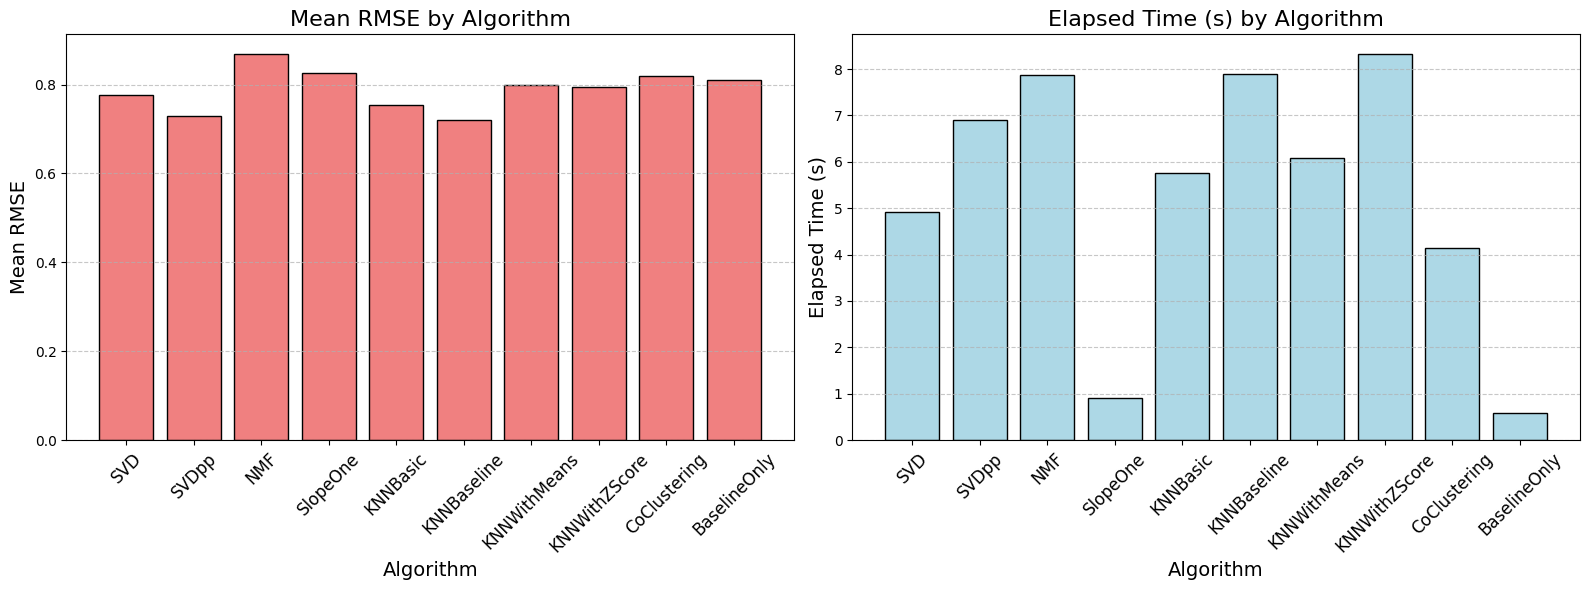

In [56]:
import matplotlib.pyplot as plt
# Tạo lưới chứa hai biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Biểu đồ 1: Mean RMSE
axes[0].bar(summary_df['Algorithm'], summary_df['Mean rmse'], color='lightcoral', edgecolor='black')
axes[0].set_title('Mean RMSE by Algorithm', fontsize=16)
axes[0].set_xlabel('Algorithm', fontsize=14)
axes[0].set_ylabel('Mean RMSE', fontsize=14)
axes[0].tick_params(axis='x', rotation=45, labelsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Biểu đồ 2: Elapsed Time (s)
axes[1].bar(summary_df['Algorithm'], summary_df['Elapsed Time (s)'], color='lightblue', edgecolor='black')
axes[1].set_title('Elapsed Time (s) by Algorithm', fontsize=16)
axes[1].set_xlabel('Algorithm', fontsize=14)
axes[1].set_ylabel('Elapsed Time (s)', fontsize=14)
axes[1].tick_params(axis='x', rotation=45, labelsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Điều chỉnh khoảng cách giữa các biểu đồ
plt.tight_layout()
plt.show()

* Chọn SVDpp với rmse thấp và thời gian nhanh

### 3.3.Huấn luyện mô hình và chạy kiểm tra kết quả

In [57]:
algorithm = SVDpp()
trainset = data.build_full_trainset()
algorithm.fit(trainset)

In [58]:
# userId = 49 has seen some movies:
userId = 49
df_select = df[(df['ma_khach_hang'] == userId) & (df['so_sao'] >=3)]
df_select = df_select.set_index('ma_san_pham')
df_select = pd.merge(df_select, products[['ma_san_pham', 'ten_san_pham']], on='ma_san_pham', how='left')
df_select.head(df_select.shape[0])

,ma_san_pham,ma_khach_hang,so_sao,ten_san_pham
0,422201123,49,4,Combo Sunplay Sữa Chống Nắng Ngăn Sạm & Hiệu C...
1,318900012,49,4,Nước Hoa Hồng Klairs Không Mùi Cho Da Nhạy Cảm...
2,318900011,49,4,Nước Hoa Hồng Klairs Dành Cho Da Nhạy Cảm 180ml


In [59]:
df_score = df[["ma_san_pham"]]
df_score

,ma_san_pham
0,308500015
1,308500015
2,422216594
3,204100075
4,422208977
...,...
21570,422206043
21571,100230057
21572,422201504
21573,358300001


In [60]:
df_score['EstimateScore'] = df_score['ma_san_pham'].apply(lambda x: algorithm.predict(userId, x).est) # est: get EstimateScore
df_score = df_score.sort_values(by=['EstimateScore'], ascending=False)

<ipython-input-60-7f2b0e64e258>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['EstimateScore'] = df_score['ma_san_pham'].apply(lambda x: algorithm.predict(userId, x).est) # est: get EstimateScore


In [61]:
df_score = df_score.drop_duplicates()
df_score.head(10)

,ma_san_pham,EstimateScore
9152,308500001,4.375112
5547,422205122,4.300714
10325,335100004,4.295225
6597,100210023,4.288495
13622,422203645,4.287235
6181,213300016,4.283059
14047,248700055,4.278759
4593,223600026,4.272054
7450,422205345,4.271826
18699,422216354,4.266564


In [62]:
df_result = pd.merge(df_score, products[['ma_san_pham', 'ten_san_pham']], on='ma_san_pham', how='left')
df_result.head(10)

,ma_san_pham,EstimateScore,ten_san_pham
0,308500001,4.375112,Sữa Rửa Mặt Naruko Dạng Bùn Tràm Trà 120ml
1,422205122,4.300714,Serum B.O.M Từ 8 Loại Trà Làm Dịu & Cấp Ẩm Da ...
2,335100004,4.295225,Kem Rửa Mặt Oxy Có Hạt Làm Sạch Sâu Giảm Nhờn ...
3,100210023,4.288495,Serum Timeless Vitamin B5 Làm Dịu & Phục Hồi D...
4,422203645,4.287235,Combo Simple Chăm Sóc Cho Da Sạch Khỏe Đàn Hồi...
5,213300016,4.283059,Sữa Chống Nắng Bioré Bảo Vệ Hoàn Hảo - Sáng Mị...
6,248700055,4.278759,Sữa Dưỡng Naris Cosmetics Hyaluronic Acid Cấp ...
7,223600026,4.272054,"Nước Tẩy Trang Senka Ngừa Mụn, Kiểm Soát Nhờn ..."
8,422205345,4.271826,"Serum Care:Nel Làm Sáng Da, Giảm Mụn Thâm 30ml"
9,422216354,4.266564,Kem Dưỡng La Roche-Posay Giảm Mụn Hiệu Quả 7.5ml


### 3.4.Xây dựng hàm tổng quát

In [63]:
def recommend_products(user_id, algorithm, min_rating, df=df, products=products, top_n=5):
    """
    Gợi ý sản phẩm và trả về bảng các sản phẩm đã đánh giá và bảng các sản phẩm được đề xuất.

    Args:
    - user_id (int): ID của người dùng.
    - df (pd.DataFrame): Dữ liệu đánh giá, bao gồm các cột 'ma_khach_hang', 'ma_san_pham', và 'so_sao'.
    - products (pd.DataFrame): Dữ liệu sản phẩm, bao gồm các cột 'ma_san_pham' và 'ten_san_pham'.
    - algorithm: Mô hình đề xuất (Surprise algorithm).
    - min_rating (int): Mức đánh giá tối thiểu để xem xét (mặc định là 3 sao).
    - top_n (int): Số sản phẩm được đề xuất hàng đầu (mặc định là 10 sản phẩm).

    Returns:
    - df_rated (pd.DataFrame): Bảng sản phẩm mà người dùng đã đánh giá từ `min_rating` trở lên.
    - df_recommend (pd.DataFrame): Bảng sản phẩm được gợi ý với điểm dự đoán cao nhất.
    """
    # 1. Lọc các sản phẩm đã được người dùng đánh giá từ min_rating trở lên
    df_rated = df[(df['ma_khach_hang'] == user_id) & (df['so_sao'] >= min_rating)]
    df_rated = df_rated.set_index('ma_san_pham')
    df_rated = pd.merge(df_rated, products[['ma_san_pham', 'ten_san_pham']], on='ma_san_pham', how='left')

    # 2. Tạo bảng chứa tất cả các sản phẩm và dự đoán điểm số cho người dùng
    df_score = df[['ma_san_pham']].drop_duplicates()  # Đảm bảo không có sản phẩm trùng lặp
    df_score['EstimateScore'] = df_score['ma_san_pham'].apply(lambda x: algorithm.predict(user_id, x).est)  # Dự đoán điểm số
    df_score = df_score.sort_values(by=['EstimateScore'], ascending=False)  # Sắp xếp theo điểm dự đoán giảm dần

    # 3. Lấy top N sản phẩm gợi ý
    df_recommend = df_score.head(top_n)
    df_recommend = pd.merge(df_recommend, products[['ma_san_pham', 'ten_san_pham']], on='ma_san_pham', how='left')

    return df_rated, df_recommend

In [64]:
# Gọi hàm với ID người dùng
user_id = 15
df_rated, df_recommend = recommend_products(user_id, algorithm, 2)

In [65]:
# Hiển thị kết quả
print("Sản phẩm đã đánh giá:")
df_rated

Sản phẩm đã đánh giá:


,ma_san_pham,ma_khach_hang,so_sao,ten_san_pham
0,318900012,15,4,Nước Hoa Hồng Klairs Không Mùi Cho Da Nhạy Cảm...
1,318900011,15,4,Nước Hoa Hồng Klairs Dành Cho Da Nhạy Cảm 180ml


In [66]:
print("Sản phẩm được gợi ý:")
df_recommend

Sản phẩm được gợi ý:


,ma_san_pham,EstimateScore,ten_san_pham
0,345800008,4.874935,Mặt Nạ Some By Mi Ngọc Trai Dưỡng Sáng Da 25g
1,222600006,4.820792,Gel Tẩy Tế Bào Chết Bio-essence Dưỡng Da Tươi ...
2,422212871,4.811334,"Combo 10 Mặt Nạ Caryophy Giảm Mụn, Thâm & Dưỡn..."
3,308500001,4.798474,Sữa Rửa Mặt Naruko Dạng Bùn Tràm Trà 120ml
4,335100004,4.786915,Kem Rửa Mặt Oxy Có Hạt Làm Sạch Sâu Giảm Nhờn ...


### 3.5 Lưu mô hình và sử dụng mô hình

In [67]:
import joblib
# Lưu mô hình vào file
joblib.dump(algorithm, 'project2/svdpp_model.joblib')

print("Mô hình đã được lưu thành công!")

Mô hình đã được lưu thành công!


In [68]:
# Tải mô hình từ file
loaded_model = joblib.load('project2/svdpp_model.joblib')
# Gọi hàm với ID người dùng
user_id = 23
df_rated, df_recommend = recommend_products(user_id, loaded_model, 2)

In [69]:
# Hiển thị kết quả
print("Sản phẩm đã đánh giá:")
df_rated

Sản phẩm đã đánh giá:


,ma_san_pham,ma_khach_hang,so_sao,ten_san_pham
0,100750038,23,5,Nước Tẩy Trang Byphasse Cho Mọi Loại Da 500ml
1,422202045,23,5,Combo Tẩy Da Chết Mặt Cocoon Cà Phê Đắk Lắk 2x...
2,418800004,23,5,"Serum 9Wishes Dưỡng Sáng Da, Giảm Thâm 25ml"
3,422207865,23,5,Sữa Rửa Mặt Cetaphil Dịu Lành Cho Da Nhạy Cảm ...
4,422207423,23,5,Combo 2 Sữa Rửa Mặt Cetaphil Dịu Nhẹ Không Xà ...
5,422202025,23,5,Tẩy Da Chết Mặt Cocoon Cà Phê Đắk Lắk 150ml
6,318900012,23,5,Nước Hoa Hồng Klairs Không Mùi Cho Da Nhạy Cảm...
7,418800002,23,5,Serum 9Wishes Dưỡng Ẩm & Làm Căng Bóng Da 25ml
8,200900037,23,5,Sữa Rửa Mặt Cetaphil Dịu Lành Cho Da Nhạy Cảm ...
9,422218631,23,5,Combo 2 Sữa Rửa Mặt Cetaphil Dịu Lành Cho Da N...


In [70]:
print("Sản phẩm được gợi ý:")
df_recommend

Sản phẩm được gợi ý:


,ma_san_pham,EstimateScore,ten_san_pham
0,422205888,5.0,Xịt Khoáng Cocoon Nghệ Hưng Yên Giúp Sáng Da 1...
1,422207023,5.0,"Dung Dịch Hada Labo Dưỡng Ẩm Tối Ưu Da Thường,..."
2,422205635,5.0,Mặt Nạ Dưỡng Da Some By Mi Tràm Trà Làm Dịu Da...
3,422212871,5.0,"Combo 10 Mặt Nạ Caryophy Giảm Mụn, Thâm & Dưỡn..."
4,422209045,5.0,Nước Tẩy Trang Swiss Image 3 Trong 1 Sạch Sâu ...


## 4.So sánh

In [77]:
from pyspark.sql import functions as F

def recommend_products_combined(user_id, customer_name, als_model, surprise_algorithm, min_rating=3, top_n=5):
    """
    Hàm tổng hợp đề xuất sản phẩm từ mô hình ALS và Surprise và trả về kết quả dưới dạng DataFrame.

    Args:
    - user_id (int): ID của người dùng.
    - customer_name (str): Tên khách hàng (cần thiết cho ALS nếu `user_id` không được cung cấp).
    - als_model: Mô hình ALS đã được huấn luyện.
    - surprise_algorithm: Mô hình Surprise đã được huấn luyện.
    - min_rating (int): Mức đánh giá tối thiểu để xem xét (mặc định là 3 sao).
    - top_n (int): Số sản phẩm được đề xuất hàng đầu (mặc định là 5 sản phẩm).

    Returns:
    - df_combined (pd.DataFrame): DataFrame tổng hợp các kết quả từ ALS và Surprise.
    """

    # Tạo một danh sách để chứa các kết quả
    combined_results = []

    # ALS Recommendation
    start_time_als = time.time()
    if customer_name:
        # Lấy `user_id` từ tên khách hàng nếu không có user_id
        user_id = df_customers.filter(F.col("ho_ten") == customer_name).select("ma_khach_hang").head()[0]

    # Tạo DataFrame từ `user_id` để dự đoán
    user_df = spark.createDataFrame([(user_id,)], ["ma_khach_hang"])
    recommendations_als = als_model.recommendForUserSubset(user_df, numItems=top_n)
    recs_als = recommendations_als.select("recommendations").collect()[0][0]
    recommended_product_ids_als = [row["ma_san_pham"] for row in recs_als]
    recommended_ratings_als = [row["rating"] for row in recs_als]
    recommended_df_als = spark.createDataFrame(
        zip(recommended_product_ids_als, recommended_ratings_als), ["ma_san_pham", "predicted_rating"]
    )
    result_als = recommended_df_als.join(df_products, "ma_san_pham").select(
        "ma_san_pham", "ten_san_pham", "predicted_rating"
    ).toPandas()

    for index, row in result_als.iterrows():
        combined_results.append({
            'ma_san_pham': row['ma_san_pham'],
            'ten_san_pham': row['ten_san_pham'],
            'predicted_rating': row['predicted_rating'],
            'model': 'ALS'
        })

    time_als = time.time() - start_time_als

    # Surprise Recommendation
    start_time_surprise = time.time()
    df_score = pd.DataFrame({'ma_san_pham': products['ma_san_pham'].unique()})
    df_score['EstimateScore'] = df_score['ma_san_pham'].apply(
        lambda x: surprise_algorithm.predict(user_id, x).est
    )
    df_score = df_score.sort_values(by=['EstimateScore'], ascending=False).head(top_n)
    df_recommend_surprise = pd.merge(
        df_score, products[['ma_san_pham', 'ten_san_pham']], on='ma_san_pham', how='left'
    )

    for index, row in df_recommend_surprise.iterrows():
        combined_results.append({
            'ma_san_pham': row['ma_san_pham'],
            'ten_san_pham': row['ten_san_pham'],
            'predicted_rating': row['EstimateScore'],
            'model': 'Surprise'
        })

    time_surprise = time.time() - start_time_surprise

    # Chuyển kết quả thành DataFrame
    df_combined = pd.DataFrame(combined_results)

    # Thêm một cột thời gian chung
    df_combined['time_taken'] = df_combined['model'].apply(lambda model: time_als if model == 'ALS' else time_surprise)

    return df_combined

In [80]:
# Ví dụ sử dụng:
df_result = recommend_products_combined(
    user_id=23,
    customer_name=None,
    als_model=ALS_model,
    surprise_algorithm=algorithm,
    min_rating=3,
    top_n=5
)

In [79]:
df[df['ma_khach_hang'] == 23]

,ma_khach_hang,ma_san_pham,so_sao
391,23,100750038,5
738,23,422202045,5
1823,23,418800004,5
2908,23,422207865,5
5164,23,422204906,1
5890,23,422207423,5
7581,23,422202025,5
9283,23,318900012,5
11652,23,418800002,5
11754,23,200900037,5


In [83]:
df_result[df_result['model'] == 'ALS']

,ma_san_pham,ten_san_pham,predicted_rating,model,time_taken
0,248700001,Sữa Rửa Mặt Naris Acmedica Chăm Sóc Da Mụn 100g,6.668929,ALS,2.733556
1,422204775,Nước Dưỡng Da Chinoshio Dokudami Chiết Xuất Lá...,6.405949,ALS,2.733556
2,248100018,Nước Hoa Hồng EVELINE Chiết Xuất Trà Matcha 400ml,6.364693,ALS,2.733556
3,422207799,Sữa Rửa Mặt Milaganics Tràm Trà Nano Nghệ Ngừa...,6.279047,ALS,2.733556
4,422205122,Serum B.O.M Từ 8 Loại Trà Làm Dịu & Cấp Ẩm Da ...,6.191239,ALS,2.733556


In [84]:
df_result[df_result['model'] == 'Surprise']

,ma_san_pham,ten_san_pham,predicted_rating,model,time_taken
5,422204775,Nước Dưỡng Da Chinoshio Dokudami Chiết Xuất Lá...,5.0,Surprise,0.033288
6,422210954,Dầu Tẩy Trang Kosé Softymo Làm Sạch Nhanh 230ml,5.0,Surprise,0.033288
7,422201092,Mặt Nạ Sur.Medic+ Cấp Nước & Cấp Ẩm Chuyên Sâu...,5.0,Surprise,0.033288
8,422200377,Kem Chống Nắng Bioderma Giảm Bóng Nhờn 40ml (M...,5.0,Surprise,0.033288
9,225200015,Mặt Nạ Ngủ Môi Care:Nel Chiết Xuất Quả Mọng 23g,5.0,Surprise,0.033288


Nhận xét lại dựa trên RMSE và các yếu tố đã có:
1. Độ chính xác của mô hình ALS:
RMSE = 0.66 cho thấy rằng mô hình ALS có khả năng dự đoán điểm số với độ chính xác tương đối tốt, bởi vì RMSE thấp hơn 1 là một dấu hiệu tích cực cho thấy mô hình không có độ sai lệch lớn so với dữ liệu thực tế.
Nếu RMSE càng thấp, mô hình sẽ càng chính xác trong việc dự đoán các sản phẩm mà người dùng có thể thích hoặc không thích. RMSE 0.66 chỉ ra rằng mô hình có thể dự đoán gần đúng các sản phẩm mà người dùng có thể đánh giá cao.
2. Đánh giá lại các mô hình:
  - ALS:
    - Với RMSE = 0.66 và sự đa dạng trong các sản phẩm được đề xuất, mô hình ALS không chỉ dự đoán tốt mà còn cá nhân hóa các đề xuất phù hợp với người dùng.
    - Điểm dự đoán (6.19 - 6.66) khá cao cho thấy các sản phẩm được đề xuất đều có thể đạt được mức đánh giá tích cực từ người dùng, và với RMSE 0.66, khả năng dự đoán chính xác sản phẩm mà người dùng thực sự yêu thích là khá cao.
    - Time Taken (2.733556 giây) vẫn là một yếu tố cần cải thiện nếu hệ thống yêu cầu thời gian phản hồi nhanh. Tuy nhiên, nếu mục tiêu là sự chính xác cao và cá nhân hóa mạnh mẽ, mô hình ALS vẫn là lựa chọn tốt.
  - Surprise:
    - Surprise đưa ra điểm dự đoán đồng đều 5.0 cho tất cả các sản phẩm, điều này có thể chỉ ra rằng mô hình này thiếu khả năng phân biệt giữa các sản phẩm trong việc dự đoán độ phù hợp với người dùng.
4. Kết luận tổng thể:
  - ALS là mô hình mạnh mẽ với RMSE thấp (0.66), cho thấy khả năng dự đoán khá chính xác và cá nhân hóa mạnh mẽ. Tuy nhiên, thời gian thực thi (2.733556 giây) có thể cần cải thiện nếu ứng dụng yêu cầu tốc độ phản hồi nhanh.
  - Surprise có thời gian thực thi nhanh và phù hợp với các hệ thống yêu cầu hiệu suất cao, nhưng thiếu tính cá nhân hóa, không phân biệt được giữa các sản phẩm, và điểm dự đoán đồng đều cho tất cả các sản phẩm có thể không mang lại trải nghiệm người dùng tối ưu.
- -> Chọn Surpirse